In [1]:
# ============================================
# 01. Setup
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
book_dir = Path("/mnt/f/book")
languages = ["english", "french", "german"]

books = pd.DataFrame([
    {"language": lang, "book": path.stem, "path": path}
    for lang in languages
    for path in sorted((book_dir / lang).glob("*.txt"))
])

display(books)

,language,book,path
0,english,alice,/mnt/f/book/english/alice.txt
1,english,mobydick,/mnt/f/book/english/mobydick.txt
2,english,pride,/mnt/f/book/english/pride.txt
3,english,sherlock,/mnt/f/book/english/sherlock.txt
4,french,candide,/mnt/f/book/french/candide.txt
5,french,madame_bovary,/mnt/f/book/french/madame_bovary.txt
6,french,notre_dame,/mnt/f/book/french/notre_dame.txt
7,german,faust,/mnt/f/book/german/faust.txt
8,german,kafka_verwandlung,/mnt/f/book/german/kafka_verwandlung.txt
9,german,nietzsche_zarathustra,/mnt/f/book/german/nietzsche_zarathustra.txt


In [3]:
# ============================================
# 02. Sequence length
# ============================================

books["n_char"] = books["path"].apply(lambda p: len(p.read_text().strip()))

display(books[["language", "book", "n_char"]])
display(books.groupby("language")["n_char"].agg(["count", "mean", "min", "max"]).round(0))

,language,book,n_char
0,english,alice,163948
1,english,mobydick,1238277
2,english,pride,748165
3,english,sherlock,581599
4,french,candide,220804
5,french,madame_bovary,677684
6,french,notre_dame,1189469
7,german,faust,207095
8,german,kafka_verwandlung,141032
9,german,nietzsche_zarathustra,538591


,count,mean,min,max
language,,,,
english,4,682997.0,163948,1238277
french,3,695986.0,220804,1189469
german,3,295573.0,141032,538591


In [4]:
# ============================================
# 03. Load k-mer counts
# ============================================

kmer_dir = Path("../results/kmers")

kmer = {}
for k in range(1, 7):
    kmer[k] = pd.read_csv(kmer_dir / f"k{k}_book_counts.tsv", sep="\t")
    print(f"k={k}: {kmer[k].shape}")

display(kmer[2].head())

k=1: (572, 6)
k=2: (11822, 6)
k=3: (121306, 6)
k=4: (646290, 6)
k=5: (1799938, 6)
k=6: (3249516, 6)


,language,book,k,kmer,count,frequency
0,dutch,camera_obscura,2,PR,398,0.001094
1,dutch,camera_obscura,2,RO,2287,0.006286
2,dutch,camera_obscura,2,OD,709,0.001949
3,dutch,camera_obscura,2,DU,276,0.000759
4,dutch,camera_obscura,2,UC,486,0.001336


In [5]:
# ============================================
# 04. Character composition (k = 1)
# ============================================

df1 = kmer[1].query("language in @languages").copy()

k1_mean = (
    df1.groupby(["language", "kmer"])["frequency"].mean()
    .unstack(fill_value=0)
)

display(k1_mean.round(4))

kmer,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
language,,,,,,,,,,,,,,,,,,,,,
english,0.0807,0.0158,0.0239,0.0425,0.1252,0.0209,0.0206,0.0663,0.0699,0.0013,...,0.0014,0.0556,0.0631,0.0924,0.0296,0.0095,0.0242,0.0014,0.0210,0.0009
french,0.0841,0.0114,0.0298,0.0405,0.1571,0.0145,0.0134,0.0295,0.0739,0.0045,...,0.0091,0.0616,0.0711,0.0784,0.0525,0.0159,0.0072,0.0035,0.0077,0.0017
german,0.0563,0.0181,0.0365,0.0492,0.1636,0.0156,0.0291,0.0597,0.0784,0.0016,...,0.0002,0.0710,0.0721,0.0590,0.0469,0.0069,0.0186,0.0001,0.0001,0.0117


In [6]:
# ============================================
# 05. Most frequent characters by language
# ============================================

k1_rank = (
    df1.groupby(["language", "kmer"], as_index=False)["frequency"].mean()
    .sort_values(["language", "frequency"], ascending=[True, False])
    .groupby("language").head(10)
)

display(k1_rank)

,language,kmer,frequency
4,english,E,0.125206
19,english,T,0.092407
0,english,A,0.080674
14,english,O,0.075079
8,english,I,0.069855
13,english,N,0.067641
7,english,H,0.066287
18,english,S,0.063146
17,english,R,0.055628
3,english,D,0.042461


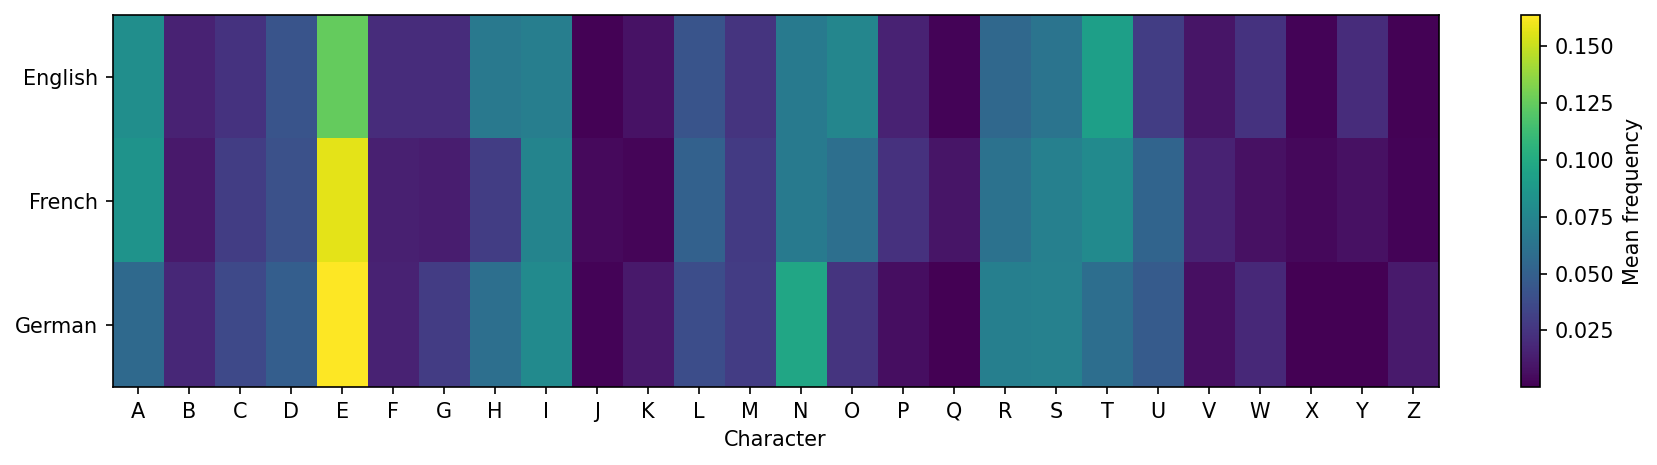

In [8]:
# ============================================
# 06. Character-frequency heatmap
# ============================================

k1_plot = k1_mean.reindex(sorted(k1_mean.columns), axis=1)

fig, ax = plt.subplots(figsize=(12, 3.2), dpi=150)
im = ax.imshow(k1_plot, aspect="auto")

ax.set_xticks(range(k1_plot.shape[1]), labels=k1_plot.columns)
ax.set_yticks(range(3), labels=["English", "French", "German"])
ax.set_xlabel("Character"); ax.set_ylabel("")
fig.colorbar(im, ax=ax, label="Mean frequency")

plt.tight_layout()
plt.show()

In [9]:
# ============================================
# 07. Character-pair composition (k = 2)
# ============================================

df2 = kmer[2].query("language in @languages").copy()

k2_mean = (
    df2.groupby(["language", "kmer"])["frequency"].mean()
    .unstack(fill_value=0)
)

k2_rank = (
    df2.groupby(["language", "kmer"], as_index=False)["frequency"].mean()
    .sort_values(["language", "frequency"], ascending=[True, False])
    .groupby("language").head(15)
)

display(k2_rank)

,language,kmer,frequency
450,english,TH,0.032084
183,english,HE,0.029614
216,english,IN,0.019109
119,english,ER,0.018750
13,english,AN,0.015381
179,english,HA,0.013226
395,english,RE,0.012743
356,english,OU,0.012019
120,english,ES,0.011740
313,english,ND,0.011649


In [10]:
# ============================================
# 08. Most variable character pairs
# ============================================

k2_diff = k2_mean.T.copy()
k2_diff["range"] = k2_diff.max(axis=1) - k2_diff.min(axis=1)
k2_diff = k2_diff.sort_values("range", ascending=False)

display(k2_diff.head(20).round(4))

language,english,french,german,range
kmer,,,,
TH,0.0321,0.0123,0.0024,0.0297
CH,0.0043,0.0055,0.0339,0.0297
EN,0.0109,0.0168,0.0361,0.0252
ER,0.0188,0.0154,0.0340,0.0186
EI,0.0042,0.0037,0.0218,0.0181
HE,0.0296,0.0130,0.0118,0.0178
IE,0.0022,0.0079,0.0171,0.0149
DE,0.0051,0.0156,0.0190,0.0139
OU,0.0120,0.0132,0.0001,0.0131
